<a href="https://colab.research.google.com/github/rauttanushka69-lgtm/Python-Basic-Projects./blob/master/Task_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
p# Import libraries
import pandas as pd
from sklearn.datasets import make_blobs

# Create synthetic dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print(df.head(10))

# Display shape
print("Shape of dataset:", df.shape)

   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846
Shape of dataset: (500, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Scale the features
X_scaled = scaler.fit_transform(df)

# Show first 5 rows of scaled data
scaled_df = pd.DataFrame(X_scaled, columns=["Feature1", "Feature2"])

print(scaled_df.head())

   Feature1  Feature2
0 -0.888474  0.629907
1 -1.028908 -1.562875
2  1.831069 -0.235113
3  0.116557  0.814671
4 -0.506563 -1.602370


In [ ]:
from sklearn.cluster import KMeans

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit model and predict cluster labels
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display first 10 rows
print(df.head(10))

   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


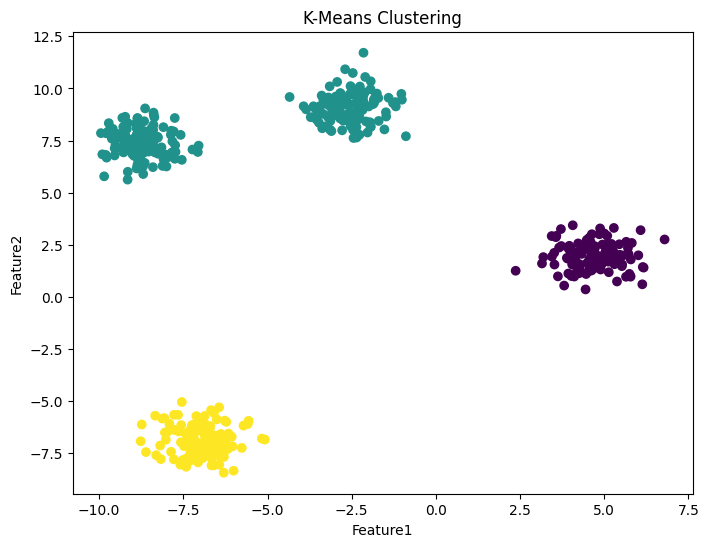

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot of clusters
plt.figure(figsize=(8,6))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

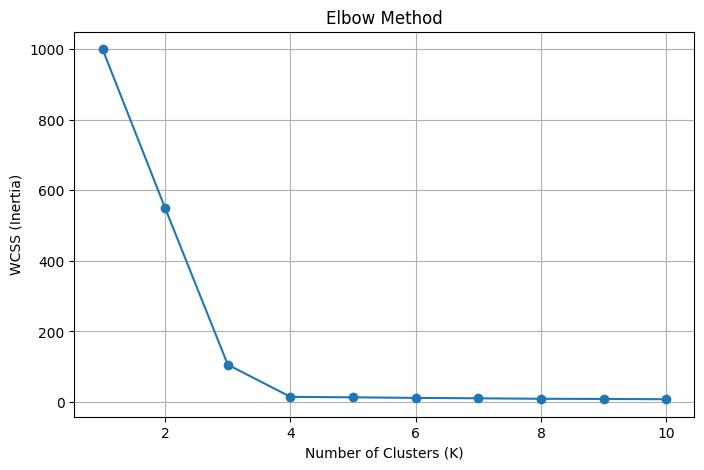

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS (Inertia) for K = 1 to 10
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Final KMeans model (Use optimal K from Q5)
kmeans_final = KMeans(n_clusters=4, random_state=42)

# Train the model
df["Final_Cluster"] = kmeans_final.fit_predict(X_scaled)

# Print number of data points in each cluster
print(df["Final_Cluster"].value_counts())

# Display first 10 rows
print(df.head(10))

Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64
   Feature1  Feature2  Cluster  Final_Cluster
0 -8.033836  6.831299        1              1
1 -8.767448 -6.918116        2              2
2  6.172741  1.407361        0              0
3 -2.783673  7.989826        1              3
4 -6.038777 -7.165762        2              2
5 -6.298392 -7.479368        2              2
6 -7.046269  7.256281        1              1
7 -6.690307 -6.915276        2              2
8  3.892545  1.873504        0              0
9 -7.317000 -6.861846        2              2


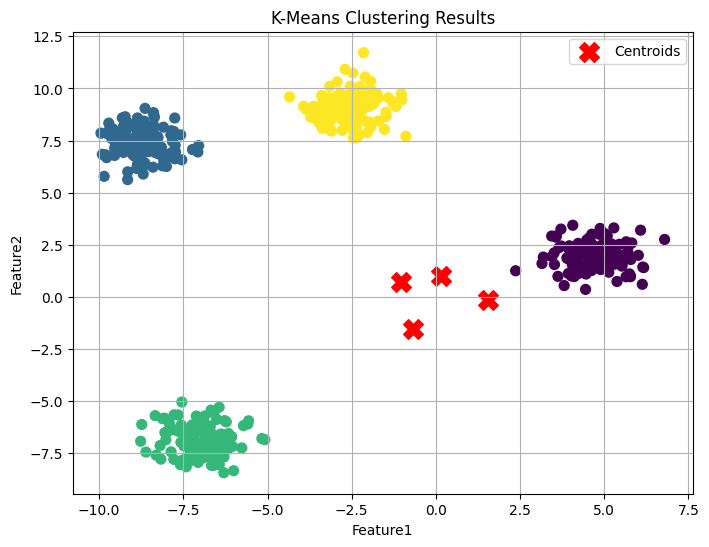

In [ ]:
import matplotlib.pyplot as plt

# Plot final clusters
plt.figure(figsize=(8,6))

plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["Final_Cluster"],
    cmap="viridis",
    s=50
)

# Plot cluster centroids
centers = kmeans_final.cluster_centers_
plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=200,
    c='red',
    label='Centroids'
)

plt.title("K-Means Clustering Results")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

# Load Iris dataset
iris = load_iris()

# Create DataFrame
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first 5 rows
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris_df)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

iris_df["Cluster"] = kmeans.fit_predict(iris_scaled)

# Display first 10 rows
print(iris_df.head(10))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  
5        1  
6        1  
7        1  
8        2  


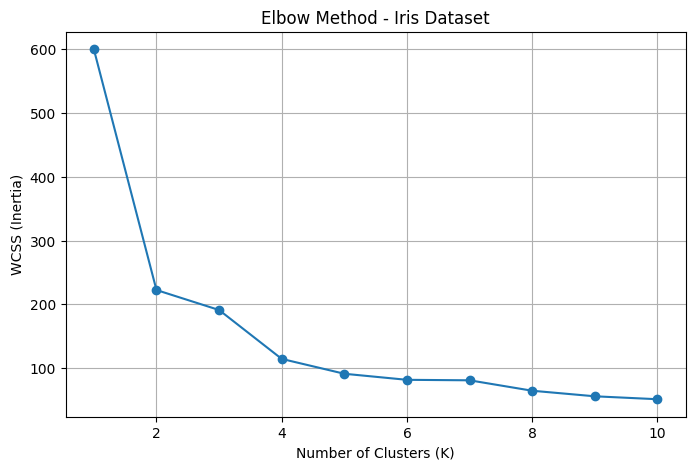

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for K = 1 to 10
wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(iris_scaled)
    wcss.append(model.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method - Iris Dataset")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

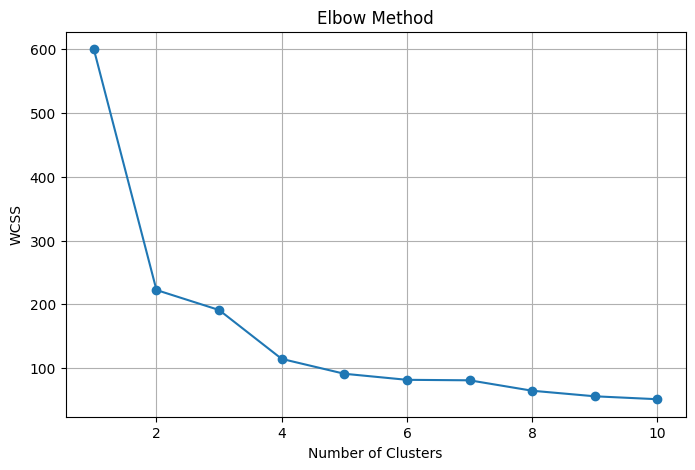

In [ ]:
wcss = []

for i in range(1, 11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4        1  


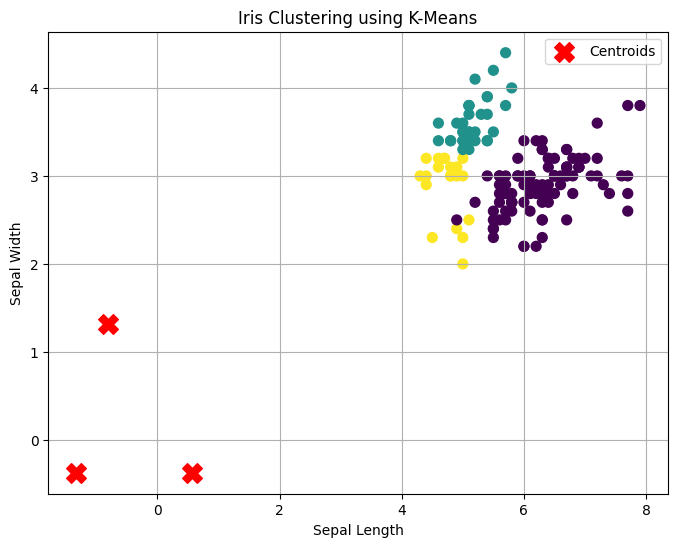

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=50
)

centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker="X",
    s=200,
    c="red",
    label="Centroids"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Clustering using K-Means")
plt.legend()
plt.grid(True)
plt.show()